# Project X -- Vinay Gannamaneni

**TA Help:** (for instance) John Smith, Alice Jones, etc., list names of any TAs who helped you

- For example: Help with figuring out how to write a function (describe the tasks that they helped you with)

**Collaboration:** My Friend in CS, My Uncle, Another Student, etc., list names of any other people who helped you

(describe the tasks that they helped you with)
- For example: helped figuring out how to load the dataset.
- Another example: helped debug error with my plot.

**Internet Resources:** Stack Exchange, Stack Overflow, etc.

(describe any information that you learned from internet resources, including the URLs)
- data frames in Pandas versus R from StackOverflow  https://stackoverflow.com/questions/8991709/why-were-pandas-merges-in-python-faster-than-data-table-merges-in-r-in-2012

**ChatGPT, Gemini, Claude, etc:** Any language models or generative AI chatbots that helped you.

(if you used any such tools, please tell us here)
- For example:  I asked ChatGPT how to define a new data frames
- Another example:  Gemini told me how to make a function for sorting my data

- ***Link to AI Chat History***: Please share a link to your chat if you used AI (ex. ChatGPT Shared Links)
**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [2]:
youtubers <- read.csv("/anvil/projects/tdm/data/youtube/most_subscribed_youtube_channels.csv")
youtubers$video.count2 <- as.numeric(gsub(",", "", youtubers$video.count))

Read the data set and clean the "video.count" column and create a numeric version

In [22]:
category_counts <- tapply(youtubers$video.count2, youtubers$category, sum, na.rm = TRUE)
print(category_counts)

                           Autos & Vehicles                Comedy 
                11230                  2874                 93562 
            Education         Entertainment      Film & Animation 
               124727               2674176                133319 
               Gaming         Howto & Style                Movies 
               427292                 81419                  5576 
                Music       News & Politics Nonprofits & Activism 
               510337               2754693                188445 
       People & Blogs        Pets & Animals  Science & Technology 
              1045091                 23960                 36622 
                Shows                Sports              Trailers 
               283027                140464                 13613 
      Travel & Events 
                  632 


Total videos per catagory

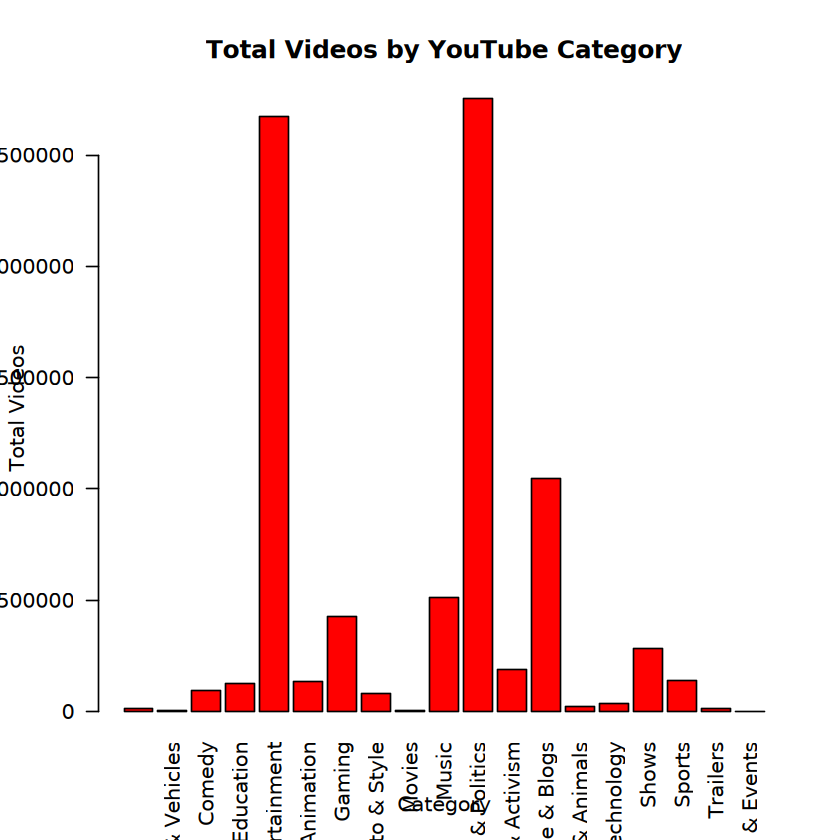

In [13]:
barplot(category_counts,
        las = 2,
        col = "red",
        main = "Total Videos by YouTube Category",
        xlab = "Category",
        ylab = "Total Videos")

"News & Politics" had most total videos overall

In [15]:
gm <- subset(youtubers, category %in% c("Gaming", "Music"))
gm_counts <- tapply(gm$video.count2, list(gm$category, gm$started), sum, na.rm = TRUE)
gm_counts

,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Gaming,17878,163116,11967,16356,15342,9998,27421,72858,32267,31332,7342,7903,9302,2952,1126,132
Music,1446,36423,51621,33451,16392,31766,89353,44299,71681,119692,5447,8477,156,121,12,NA


Total videos by each catagory by started year

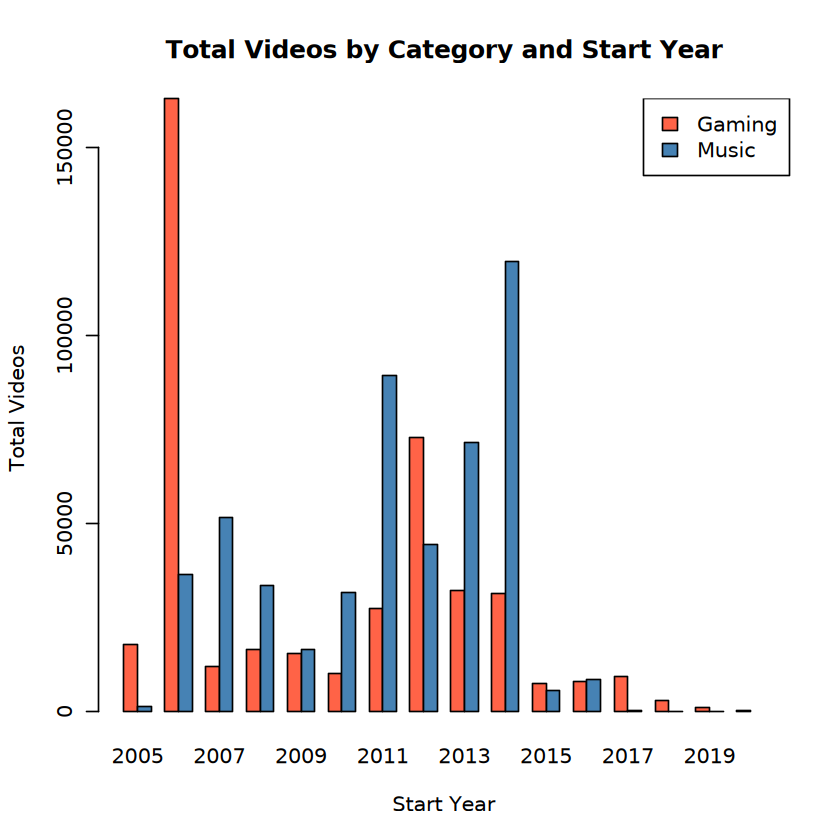

In [18]:
barplot(gm_counts,
        beside = TRUE,
        col = c("tomato", "steelblue"),
        main = "Total Videos by Category and Start Year",
        xlab = "Start Year",
        ylab = "Total Videos")
legend("topright", legend = rownames(gm_counts), fill = c("tomato", "steelblue"))

Gaming channels started in 2006 produced the most videos overall

In [21]:
avg_videos_year <- tapply(youtubers$video.count2, youtubers$started, mean, na.rm = TRUE)
print(avg_videos_year)

     1970      2005      2006      2007      2008      2009      2010      2011 
  540.000 15480.409 16612.625 24476.800 14807.333 10564.381  9957.319  5772.118 
     2012      2013      2014      2015      2016      2017      2018      2019 
 7142.812  7368.140  8370.807  4237.699  2594.442  5168.783  6515.543  2673.560 
     2020      2021 
 1385.000   696.750 


Average video count for each start year

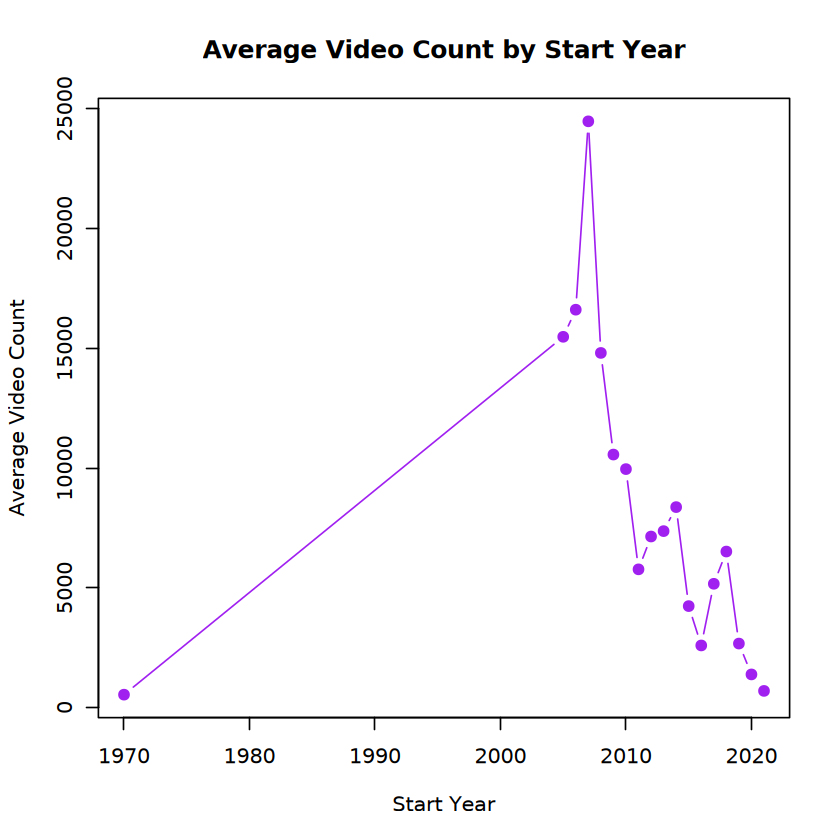

In [23]:
plot(names(avg_videos_year), avg_videos_year,
     type = "b",
     pch = 19,
     col = "purple",
     main = "Average Video Count by Start Year",
     xlab = "Start Year",
     ylab = "Average Video Count")

Around 14,807 videos per channel in 2008

## Question 2

In [50]:
ts_songs <- read.csv2("/anvil/projects/tdm/data/spotify/taylor_swift_discography_updated.csv")
dim(ts_songs)

[1] 577  28

In [92]:
ts_songs <- ts_songs[ , !(names(ts_songs) %in% "track_lyrics")]
head(ts_songs)

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,numeric_streams,cleaned_streams
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
1,0,Fortnight (feat. Post Malone),Synth Pop,Single,228965,Post Malone,No,0,648525069,1,The Tortured Poets Department: The Anthology,1,Pop,Compilation/Deluxe,19/4/2024,0,Complicated love/Looking for love,spotify:track:6dODwocEuGzHAavXqTbwHv,0.502,0.504,0.386,1.53e-05,0.0961,-10.976,0.0308,192.004,0.281,648525069,648525069
2,1,The Tortured Poets Department,Synth Pop,B-Side,293048,No,No,0,206954130,6,The Tortured Poets Department: The Anthology,2,Pop,Compilation/Deluxe,19/4/2024,0,Complicated love/Looking for love,spotify:track:4PdLaGZubp4lghChqp8erB,0.0483,0.604,0.428,0.0,0.126,-8.441,0.0255,110.259,0.292,206954130,206954130
3,2,My Boy Only Breaks His Favorite Toys,Synth Pop,B-Side,203801,No,No,0,238016975,7,The Tortured Poets Department: The Anthology,3,Pop,Compilation/Deluxe,19/4/2024,0,Broken heart/Sadness,spotify:track:7uGYWMwRy24dm7RUDDhUlD,0.137,0.596,0.563,0.0,0.302,-7.362,0.0269,97.073,0.481,238016975,238016975
4,3,Down Bad,R&B,B-Side,261228,No,No,0,318375377,2,The Tortured Poets Department: The Anthology,4,Pop,Compilation/Deluxe,19/4/2024,0,Broken heart/Sadness,spotify:track:1kbEbBdEgQdQeLXCJh28pJ,0.56,0.541,0.366,"1,00E-06",0.0946,-10.412,0.0748,159.707,0.168,318375377,318375377
5,4,"So Long, London",Synth Pop,B-Side,262974,No,No,0,253712712,4,The Tortured Poets Department: The Anthology,5,Pop,Compilation/Deluxe,19/4/2024,0,Broken heart/Sadness,spotify:track:7wAkQFShJ27V8362MqevQr,0.73,0.423,0.533,0.00264,0.0816,-11.388,0.322,160.218,0.248,253712712,253712712
6,5,But Daddy I Love Him,Pop Rock,B-Side,340428,No,No,0,229410536,9,The Tortured Poets Department: The Anthology,6,Pop,Compilation/Deluxe,19/4/2024,0,Complicated love/Looking for love,spotify:track:4QMgEffJQuKtjCNvqfRZ0m,0.384,0.521,0.72,0.0,0.135,-7.684,0.104,79.943,0.438,229410536,229410536


Removed the "lyrics" column

In [34]:
ts_songs$energy <- as.numeric(ts_songs$energy)
summary(ts_songs$energy)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.1180  0.4170  0.5700  0.5649  0.7200  0.9500 

Check "energy" numeric forms to get statistics on median, min, and max

The maximum energy level possible is 0.950. The minimum energy level possible is 0.008

In [40]:
find_songs_with_energy <- function(input_df, threshold) {
  my_output <- input_df[input_df$energy >= threshold, ]
  return(my_output)
}

medianset <- median(ts_songs$energy, na.rm = TRUE)

Use function to get all high energy songs

In [59]:
high_energy_df <- find_songs_with_energy(ts_songs, medianset)
nrow(high_energy_df)

[1] 289

289 songs had high energy in total

In [69]:
find_songs_by_album <- function(input_df, album_name) {
  input_df$album <- trimws(input_df$album)
  album_songs <- input_df[tolower(input_df$album) == tolower(album_name), ]
  
  return(album_songs)
}

Build function to find songs by album

In [70]:
tortured_poets <- find_songs_by_album(ts_songs, "The Tortured Poets Department: The Anthology")
nrow(tortured_poets)

[1] 31

The funtion works cus "The Tortured Poets Department: The Anthology" contains 31 songs

## Question 3

In [74]:
ts_songs$numeric_streams <- as.numeric(ts_songs$spotify_streams)
problematic_values <- ts_songs[is.na(ts_songs$numeric_streams) & !is.na(ts_songs$spotify_streams), "spotify_streams"]
problematic_values

Warning message:
"NAs introduced by coercion"


[1] "102.221.045"   "151.282.408"   "182.418.311"   "118.458.965"  
  [5] "88.205.974"    "101.800.187"   "77.667.730"    "75.816.684"   
  [9] "695.045.271"   "64.895.368"    "238.858.492"   "66.435.115"   
 [13] "86.966.267"    "65.608.381"    "67.947.237"    "106.436.747"  
 [17] "239.579.759"   "161.739.029"   "243.929.951"   "97.666.137"   
 [21] "327.037.965"   "57.248.658"    "102.221.045"   "151.282.408"  
 [25] "182.418.311"   "118.458.965"   "88.205.974"    "101.800.187"  
 [29] "77.667.730"    "75.816.684"    "695.045.271"   "64.895.368"   
 [33] "238.858.492"   "66.435.115"    "86.966.267"    "65.608.381"   
 [37] "67.947.237"    "106.436.747"   "239.579.759"   "161.739.029"  
 [41] "243.929.951"   "97.666.137"    "327.037.965"   "161.201.338"  
 [45] "111.149.636"   "180.262.965"   "95.341.130"    "99.582.468"   
 [49] "91.554.198"    "89.206.080"    "52.613.223"    "256.720.162"  
 [53] "116.688.485"   "44.117.403"    "72.179.901"    "72.138.383"   
 [57] "119.043.402"   "50.628.387"    "37.442.081"    "79.599.951"   
 [61] "75.501.290"    "233.537.019"   "77.280.948"    "85.579.355"   
 [65] "78.097.730"    "685.569.376"   "442.240.497"   "1.497.861.842"
 [69] "418.499.855"   "558.461.539"   "631.931.332"   "289.677.180"  
 [73] "379.998.152"   "511.571.475"   "263.703.912"   "737.680.743"  
 [77] "265.543.423"   "328.656.338"   "269.420.309"   "175.821.082"  
 [81] "176.277.983"   "148.303.282"   "118.355.491"   "257.804.372"  
 [85] "123.378.107"   "177.054.741"   "172.680.008"   "86.528.064"   
 [89] "685.569.376"   "442.240.497"   "1.497.861.842" "418.499.855"  
 [93] "558.461.539"   "631.931.332"   "289.677.180"   "379.998.152"  
 [97] "511.571.475"   "263.703.912"   "737.680.743"   "265.543.423"  
[101] "328.656.338"   "269.420.309"   "175.821.082"   "176.277.983"  
[105] "148.303.282"   "118.355.491"   "257.804.372"   "123.378.107"  
[109] "685.569.376"   "442.240.497"   "1.497.861.842" "418.499.855"  
[113] "558.461.539"   "631.931.332"   "289.677.180"   "379.998.152"  
[117] "511.571.475"   "263.703.912"   "737.680.743"   "265.543.423"  
[121] "328.656.338"   "119.887.717"   "276.457.730"   "107.168.641"  
[125] "331.115.790"   "249.885.271"   "265.698.765"   "89.369.701"   
[129] "315.588.138"   "86.371.415"    "108.741.392"   "84.058.644"   
[133] "93.349.578"    "74.802.137"    "144.156.621"   "68.667.868"   
[137] "98.591.643"    "69.027.319"    "108.053.400"   "56.901.647"   
[141] "51.126.307"    "42.569.086"    "139.140.884"   "209.924.444"  
[145] "118.151.653"   "185.024.136"   "206.457.482"   "90.351.777"   
[149] "135.457.781"   "166.946.516"   "810.542.565"   "276.701.835"  
[153] "97.490.294"    "714.184.368"   "86.368.640"    "94.810.816"   
[157] "619.978.693"   "64.707.634"    "55.729.532"    "70.295.638"   
[161] "397.666.679"   "107.430.716"   "50.543.835"    "43.303.976"   
[165] "54.359.548"    "55.397.353"    "50.407.943"    "39.608.696"   
[169] "35.505.550"    "69.531.567"    "51.835.918"    "109.187.805"  
[173] "358.733.130"   "57.957.104"    "76.512.224"    "68.743.624"   
[177] "53.973.432"    "814.114.651"   "588.394.719"   "279.044.935"  
[181] "260.055.245"   "297.807.837"   "266.696.518"   "180.744.525"  
[185] "168.010.057"   "174.430.479"   "211.246.717"   "180.507.774"  
[189] "190.498.817"   "205.207.043"   "119.250.347"   "208.212.731"  
[193] "315.084.417"   "105.356.578"   "814.114.651"   "588.394.719"  
[197] "279.044.935"   "260.055.245"   "297.807.837"   "266.696.518"  
[201] "180.744.525"   "168.010.057"   "174.430.479"   "211.246.717"  
[205] "180.507.774"   "190.498.817"   "205.207.043"   "119.250.347"  
[209] "208.212.731"   "552.789.777"   "1.240.468.789" "350.113.872"  
[213] "732.129.402"   "456.830.802"   "401.624.104"   "298.361.936"  
[217] "1.039.423.219" "375.813.987"   "389.023.820"   "351.443.321"  
[221] "206.915.468"   "179.012.062"   "339.198.629"   "202.357.820"  
[225] "180.324.854"   "147.911.887"   "17.256.353"    "22.319.608"   
[229] "13.10

Identify values that became NA after conversion

In [76]:
ts_songs$cleaned_streams <- gsub("\\.", "", ts_songs$spotify_streams)
ts_songs$numeric_streams <- as.numeric(ts_songs$cleaned_streams)

Clean the "spotify_streams" column by removing extra characters and convert cleaned values to numeric values

In [79]:
evermore <- find_songs_by_album(ts_songs, "evermore (deluxe version)")

Use the "find_songs_by_album" function to extract all songs from "evermore (deluxe version)"

The "spotify_streams" column couldn't be immediately converted to numeric because some values in the spotify_streams column contained more than one '.' character. R treats any value with multiple '.' as invalid for numeric conversion, so they became NA.

In [81]:
nrow(evermore)

[1] 17

17 songs were in "evermore (deluxe version)"

## Question 4

In [94]:
ts_songs <- ts_songs[ , !(names(ts_songs) %in% "track_lyrics")]
ts_1989 <- find_songs_by_album(ts_songs, "1989 (Taylor's Version) [Deluxe]")
nrow(ts_1989)

[1] 22

In [95]:
head(ts_1989)

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,numeric_streams,cleaned_streams
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
48,47,Welcome To New York (Taylor's Version),Dance Pop,B-Side,212600,No,No,0,102.221.045,6,1989 (Taylor's Version) [Deluxe],1,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:4WUepByoeqcedHoYhSNHRt,0.00942,0.757,0.61,3.66e-05,0.367,-4.84,0.0327,116.998,0.685,102221045,102221045
49,48,Blank Space (Taylor's Version),Electropop,B-Side,231833,No,No,0,151.282.408,3,1989 (Taylor's Version) [Deluxe],2,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:0108kcWLnn2HlH2kedi1gn,0.0885,0.733,0.733,0.0,0.168,-5.376,0.067,96.057,0.701,151282408,151282408
50,49,Style (Taylor's Version),Synth Pop,B-Side,231000,No,No,0,182.418.311,1,1989 (Taylor's Version) [Deluxe],3,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:3Vpk1hfMAQme8VJ0SNRSkd,0.000421,0.511,0.822,0.0197,0.0899,-4.785,0.0397,94.868,0.305,182418311,182418311
51,50,Out Of The Woods (Taylor's Version),Synth Pop,B-Side,235800,No,No,0,118.458.965,8,1989 (Taylor's Version) [Deluxe],4,Pop,Compilation/Deluxe,27/10/2023,0,Complicated love/Losing love,spotify:track:1OcSfkeCg9hRC2sFKB4IMJ,0.000537,0.545,0.885,5.59e-05,0.385,-5.968,0.0447,92.021,0.206,118458965,118458965
52,51,All You Had To Do Was Stay (Taylor's Version),Synth Pop,B-Side,193289,No,No,0,88.205.974,10,1989 (Taylor's Version) [Deluxe],5,Pop,Compilation/Deluxe,27/10/2023,0,Broken heart/Anger,spotify:track:2k0ZEeAqzvYMcx9Qt5aClQ,0.000656,0.588,0.721,0.0,0.131,-5.579,0.0317,96.997,0.52,88205974,88205974
53,52,Shake It Off (Taylor's Version),Dance Pop,B-Side,219209,No,No,0,101.800.187,11,1989 (Taylor's Version) [Deluxe],6,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:50yNTF0Od55qnHLxYsA5Pw,0.0121,0.636,0.808,2.18e-05,0.359,-5.693,0.0729,160.058,0.917,101800187,101800187


In [100]:
ts_1989$duration_sec <- ts_1989$duration_ms / 1000
ts_1989$duration_min <- ts_1989$duration_sec / 60

convert_duration <- function(df) {
  df$duration_sec <- df$duration_ms / 1000
  df$duration_min <- df$duration_sec / 60
  return(df)
}

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,numeric_streams,cleaned_streams,duration_sec,duration_min
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
48,47,Welcome To New York (Taylor's Version),Dance Pop,B-Side,212600,No,No,0,102.221.045,6,1989 (Taylor's Version) [Deluxe],1,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:4WUepByoeqcedHoYhSNHRt,0.00942,0.757,0.61,3.66e-05,0.367,-4.84,0.0327,116.998,0.685,102221045,102221045,212.600,3.543333
49,48,Blank Space (Taylor's Version),Electropop,B-Side,231833,No,No,0,151.282.408,3,1989 (Taylor's Version) [Deluxe],2,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:0108kcWLnn2HlH2kedi1gn,0.0885,0.733,0.733,0.0,0.168,-5.376,0.067,96.057,0.701,151282408,151282408,231.833,3.863883
50,49,Style (Taylor's Version),Synth Pop,B-Side,231000,No,No,0,182.418.311,1,1989 (Taylor's Version) [Deluxe],3,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:3Vpk1hfMAQme8VJ0SNRSkd,0.000421,0.511,0.822,0.0197,0.0899,-4.785,0.0397,94.868,0.305,182418311,182418311,231.000,3.850000
51,50,Out Of The Woods (Taylor's Version),Synth Pop,B-Side,235800,No,No,0,118.458.965,8,1989 (Taylor's Version) [Deluxe],4,Pop,Compilation/Deluxe,27/10/2023,0,Complicated love/Losing love,spotify:track:1OcSfkeCg9hRC2sFKB4IMJ,0.000537,0.545,0.885,5.59e-05,0.385,-5.968,0.0447,92.021,0.206,118458965,118458965,235.800,3.930000
52,51,All You Had To Do Was Stay (Taylor's Version),Synth Pop,B-Side,193289,No,No,0,88.205.974,10,1989 (Taylor's Version) [Deluxe],5,Pop,Compilation/Deluxe,27/10/2023,0,Broken heart/Anger,spotify:track:2k0ZEeAqzvYMcx9Qt5aClQ,0.000656,0.588,0.721,0.0,0.131,-5.579,0.0317,96.997,0.52,88205974,88205974,193.289,3.221483
53,52,Shake It Off (Taylor's Version),Dance Pop,B-Side,219209,No,No,0,101.800.187,11,1989 (Taylor's Version) [Deluxe],6,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:50yNTF0Od55qnHLxYsA5Pw,0.0121,0.636,0.808,2.18e-05,0.359,-5.693,0.0729,160.058,0.917,101800187,101800187,219.209,3.653483


Create new columns for duration in seconds and minutes and create function to covert duration

In [103]:
ts_1989_converted <- convert_duration(ts_1989)
head(ts_1989_converted)

,X...ID,track_name,track_musical_genre,track_type,duration_ms,feature,track_videoclip,videoclip_views,spotify_streams,spotify_global_peak,album,track_number,album_musical_genre,album_type,release_date,album_physical_sales,track_theme,uri,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,numeric_streams,cleaned_streams,duration_sec,duration_min
,<int>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
48,47,Welcome To New York (Taylor's Version),Dance Pop,B-Side,212600,No,No,0,102.221.045,6,1989 (Taylor's Version) [Deluxe],1,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:4WUepByoeqcedHoYhSNHRt,0.00942,0.757,0.61,3.66e-05,0.367,-4.84,0.0327,116.998,0.685,102221045,102221045,212.600,3.543333
49,48,Blank Space (Taylor's Version),Electropop,B-Side,231833,No,No,0,151.282.408,3,1989 (Taylor's Version) [Deluxe],2,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:0108kcWLnn2HlH2kedi1gn,0.0885,0.733,0.733,0.0,0.168,-5.376,0.067,96.057,0.701,151282408,151282408,231.833,3.863883
50,49,Style (Taylor's Version),Synth Pop,B-Side,231000,No,No,0,182.418.311,1,1989 (Taylor's Version) [Deluxe],3,Pop,Compilation/Deluxe,27/10/2023,0,New love,spotify:track:3Vpk1hfMAQme8VJ0SNRSkd,0.000421,0.511,0.822,0.0197,0.0899,-4.785,0.0397,94.868,0.305,182418311,182418311,231.000,3.850000
51,50,Out Of The Woods (Taylor's Version),Synth Pop,B-Side,235800,No,No,0,118.458.965,8,1989 (Taylor's Version) [Deluxe],4,Pop,Compilation/Deluxe,27/10/2023,0,Complicated love/Losing love,spotify:track:1OcSfkeCg9hRC2sFKB4IMJ,0.000537,0.545,0.885,5.59e-05,0.385,-5.968,0.0447,92.021,0.206,118458965,118458965,235.800,3.930000
52,51,All You Had To Do Was Stay (Taylor's Version),Synth Pop,B-Side,193289,No,No,0,88.205.974,10,1989 (Taylor's Version) [Deluxe],5,Pop,Compilation/Deluxe,27/10/2023,0,Broken heart/Anger,spotify:track:2k0ZEeAqzvYMcx9Qt5aClQ,0.000656,0.588,0.721,0.0,0.131,-5.579,0.0317,96.997,0.52,88205974,88205974,193.289,3.221483
53,52,Shake It Off (Taylor's Version),Dance Pop,B-Side,219209,No,No,0,101.800.187,11,1989 (Taylor's Version) [Deluxe],6,Pop,Compilation/Deluxe,27/10/2023,0,Happiness,spotify:track:50yNTF0Od55qnHLxYsA5Pw,0.0121,0.636,0.808,2.18e-05,0.359,-5.693,0.0729,160.058,0.917,101800187,101800187,219.209,3.653483


Now we have "duration_ms" converted into "duration_min" and "duration_sec" in the above data set

## Question 5

In [113]:
youtubers$subscribers2 <- as.numeric(gsub(",", "", youtubers$subscribers))

top_youtuber_by_genre <- function(df, genre) {
  genre_rows <- df[df$category == genre, ]
  max_row <- genre_rows[which.max(genre_rows$subscribers2), ]
  
  return(max_row)
}

Convert subscribers column to numeric and build a function to find the top-subscribed Youtuber in a genre

In [114]:
top_gaming <- top_youtuber_by_genre(youtubers, "Gaming")
top_gaming$Youtuber
top_gaming$subscribers2

[1] "PewDiePie"

[1] 1.11e+08

Test the function and cross check results which are "PewDiePie", with 111,000,000 subscribers

In [115]:
table(youtubers$category)


                           Autos & Vehicles                Comedy 
                   27                     1                    63 
            Education         Entertainment      Film & Animation 
                   46                   241                    52 
               Gaming         Howto & Style                Movies 
                  102                    45                     2 
                Music       News & Politics Nonprofits & Activism 
                  222                    27                     2 
       People & Blogs        Pets & Animals  Science & Technology 
                  119                     6                    18 
                Shows                Sports              Trailers 
                   14                    10                     2 
      Travel & Events 
                    1 

In [117]:
top_music <- top_youtuber_by_genre(youtubers, "Music")
top_music$Youtuber
top_music$subscribers2

[1] "T-Series"

[1] 2.22e+08

I used the second catagory "Music" with output as "T-Series", with 

Markdown notes and full English sentences and analysis written here.

Markdown notes and full English sentences and analysis written here.

Markdown notes and full English sentences and analysis written here.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
